In [94]:
# ==========================================
# Imports
# ==========================================

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit

import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [95]:
# ==========================================
# Dataset Path
# ==========================================

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

csv_path = os.path.join(DATASET_PATH, "Data_Entry_2017.csv")

df = pd.read_csv(csv_path)

df = df.drop(columns=["Unnamed: 11"])

print(df.shape)

(112120, 11)


In [96]:
# ==========================================
# Create Image Path Mapping
# ==========================================

image_paths = glob.glob(
    os.path.join(DATASET_PATH, "images_*", "images", "*.png")
)

print("Images Found:", len(image_paths))

image_lookup = {
    os.path.basename(path): path
    for path in image_paths
}

df["Image Path"] = df["Image Index"].map(image_lookup)

print(df[["Image Index", "Image Path"]].head())

Images Found: 112120
        Image Index                                         Image Path
0  00000001_000.png  /kaggle/input/datasets/organizations/nih-chest...
1  00000001_001.png  /kaggle/input/datasets/organizations/nih-chest...
2  00000001_002.png  /kaggle/input/datasets/organizations/nih-chest...
3  00000002_000.png  /kaggle/input/datasets/organizations/nih-chest...
4  00000003_000.png  /kaggle/input/datasets/organizations/nih-chest...


In [97]:
print(df["Image Path"].isnull().sum())

0


In [98]:
print(df.shape)

(112120, 12)


In [99]:
print("Images Found:", len(image_paths))

Images Found: 112120


In [100]:
df[["Image Index","Image Path"]].head()

,Image Index,Image Path
0,00000001_000.png,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,/kaggle/input/datasets/organizations/nih-chest...


In [101]:
df["Image Path"].isnull().sum()

np.int64(0)

In [102]:
# =====================================================
# Multi-Label Encoding
# =====================================================

DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

for disease in DISEASES:
    df[disease] = df["Finding Labels"].apply(
        lambda x: 1 if disease in x else 0
    )

print("Multi-label encoding completed.")

df[DISEASES].head()

Multi-label encoding completed.


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [103]:
# ==========================================
# Patient-wise Train-Test Split
# ==========================================

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    test_size=0.20,
    n_splits=1,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        df,
        groups=df["Patient ID"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)

temp_df = df.iloc[temp_idx].reset_index(drop=True)

print("Train Images :", len(train_df))
print("Temporary Images :", len(temp_df))

Train Images : 89826
Temporary Images : 22294


In [104]:
# ==========================================
# Validation-Test Split
# ==========================================

gss2 = GroupShuffleSplit(
    test_size=0.50,
    n_splits=1,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print()

print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images :", len(test_df))


Training Images : 89826
Validation Images : 11679
Testing Images : 10615


In [105]:
# ==========================================
# Check Patient Leakage
# ==========================================

train_patients = set(train_df["Patient ID"])

val_patients = set(val_df["Patient ID"])

test_patients = set(test_df["Patient ID"])

print("Train ∩ Validation :", len(train_patients & val_patients))

print("Train ∩ Test :", len(train_patients & test_patients))

print("Validation ∩ Test :", len(val_patients & test_patients))

Train ∩ Validation : 0
Train ∩ Test : 0
Validation ∩ Test : 0


In [106]:
# =====================================================
# Verify Disease Counts
# =====================================================

label_counts = df[DISEASES].sum().sort_values(ascending=False)

print(label_counts)

Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


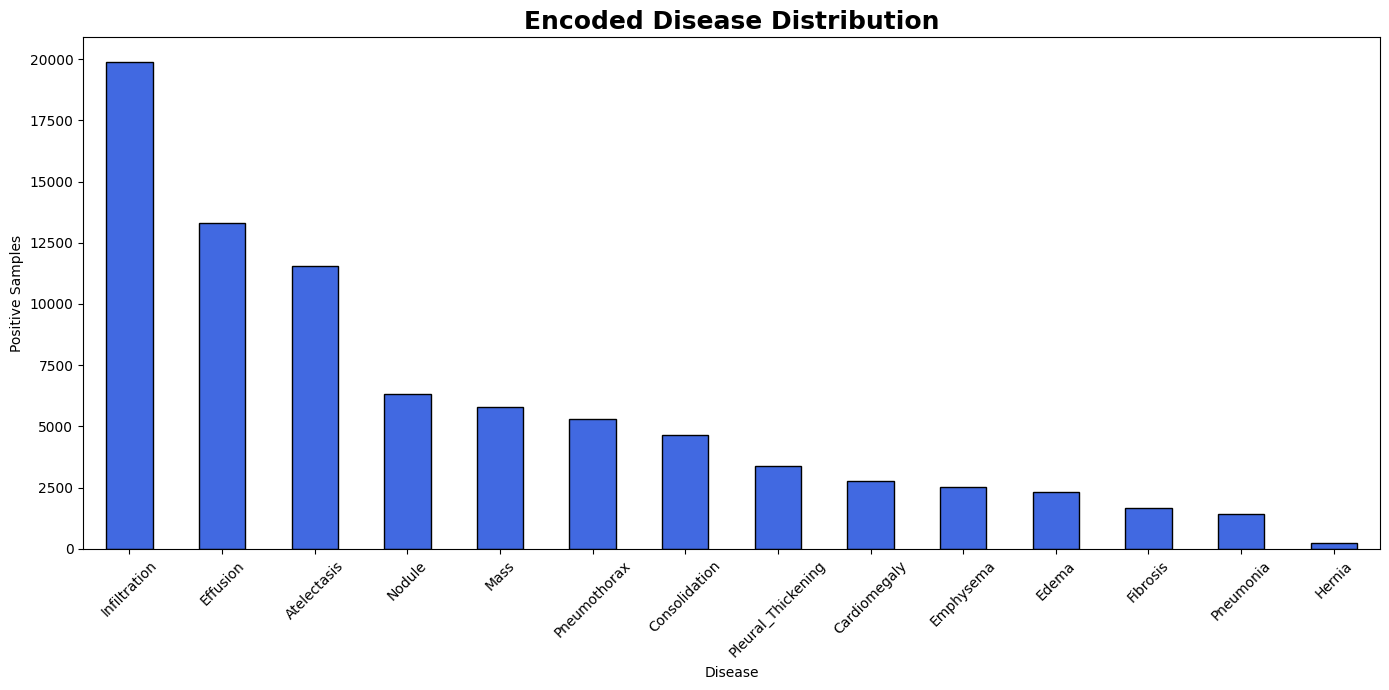

In [107]:
# =====================================================
# Encoded Label Distribution
# =====================================================

plt.figure(figsize=(14,7))

label_counts.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Encoded Disease Distribution",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Disease")

plt.ylabel("Positive Samples")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [108]:
# ====================================================
# Prepare Labels
# ====================================================

DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

print("Number of Diseases:", len(DISEASES))

print("\nDisease Labels:")
print(DISEASES)

Number of Diseases: 14

Disease Labels:
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [109]:
# ====================================================
# Create Input Arrays
# ====================================================

train_paths = train_df["Image Path"].values

train_labels = train_df[DISEASES].values.astype("float32")

val_paths = val_df["Image Path"].values

val_labels = val_df[DISEASES].values.astype("float32")

test_paths = test_df["Image Path"].values

test_labels = test_df[DISEASES].values.astype("float32")

print("Training Images :", len(train_paths))
print("Validation Images:", len(val_paths))
print("Testing Images :", len(test_paths))

print("\nLabel Shape:", train_labels.shape)

Training Images : 89826
Validation Images: 11679
Testing Images : 10615

Label Shape: (89826, 14)


In [110]:
print(df.columns)

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Image Path',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
       'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
       'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'],
      dtype='object')


In [111]:
print(train_df.columns)

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Image Path',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
       'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
       'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'],
      dtype='object')


In [112]:
# ====================================================
# Inspect One Training Sample
# ====================================================

sample_index = 0

print("Image Path:\n")
print(train_paths[sample_index])

print("\nEncoded Label:\n")
print(train_labels[sample_index])

Image Path:

/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000001_000.png

Encoded Label:

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [113]:
# ====================================================
# Decode Encoded Labels
# ====================================================

label_vector = train_labels[0]

print("Diseases Present:\n")

for disease, value in zip(DISEASES, label_vector):
    if value == 1:
        print("✅", disease)

Diseases Present:

✅ Cardiomegaly


In [114]:
# ====================================================
# Image Loading Function
# ====================================================

IMAGE_SIZE = 224

def load_image(image_path, label):
    """
    Reads an image from disk and preprocesses it.
    """

    # Read image
    image = tf.io.read_file(image_path)

    # Decode PNG
    image = tf.image.decode_png(image, channels=3)

    # Resize image
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Normalize pixels
    image = image / 255.0

    return image, label

print("Image loading function created successfully.")

Image loading function created successfully.


In [115]:
# ====================================================
# Test Image Loader
# ====================================================

sample_image, sample_label = load_image(
    train_paths[0],
    train_labels[0]
)

print("Image Shape :", sample_image.shape)

print("Label Shape :", sample_label.shape)

print("Minimum Pixel :", tf.reduce_min(sample_image).numpy())

print("Maximum Pixel :", tf.reduce_max(sample_image).numpy())

Image Shape : (224, 224, 3)
Label Shape : (14,)
Minimum Pixel : 0.0
Maximum Pixel : 0.9995595


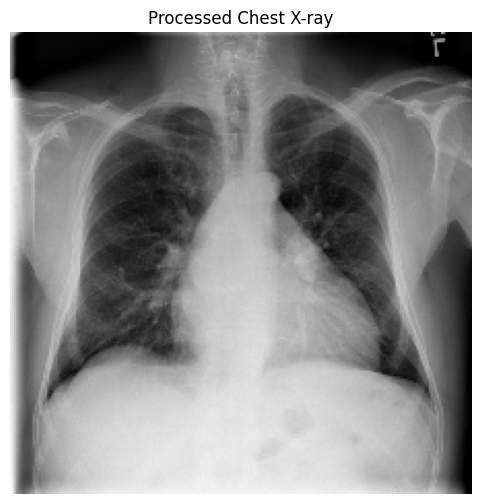

In [116]:
# ====================================================
# Display Processed Image
# ====================================================

plt.figure(figsize=(6,6))

plt.imshow(sample_image)

plt.title("Processed Chest X-ray")

plt.axis("off")

plt.show()

In [117]:
# ====================================================
# Create TensorFlow Training Dataset
# ====================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(14,), dtype=tf.float32, name=None))>


In [118]:
# ====================================================
# Validation Dataset
# ====================================================

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_dataset = val_dataset.map(
    load_image,
    
    num_parallel_calls=tf.data.AUTOTUNE
)

print(val_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(14,), dtype=tf.float32, name=None))>


In [119]:
# ====================================================
# Test Dataset
# ====================================================

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

print(test_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(14,), dtype=tf.float32, name=None))>


Image Shape : (224, 224, 3)
Label Shape : (14,)


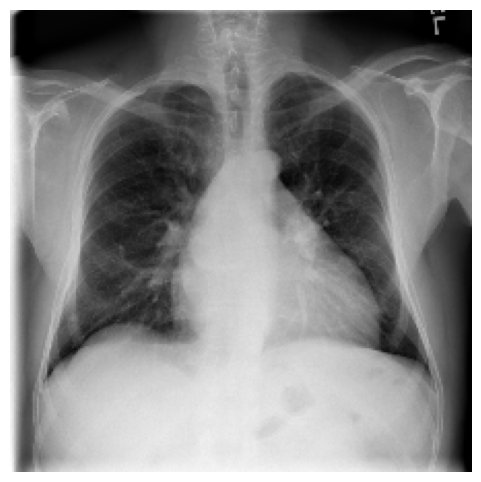

In [120]:
# ====================================================
# Inspect TensorFlow Dataset
# ====================================================

for image, label in train_dataset.take(1):

    print("Image Shape :", image.shape)

    print("Label Shape :", label.shape)

    plt.figure(figsize=(6,6))

    plt.imshow(image)

    plt.axis("off")

    plt.show()

In [121]:
# ====================================================
# Batch and Prefetch
# ====================================================

BATCH_SIZE = 32

train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets ready for training!")

Datasets ready for training!


In [122]:
# ====================================================
# Data Augmentation
# ====================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.05),

    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.RandomContrast(0.10)

])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


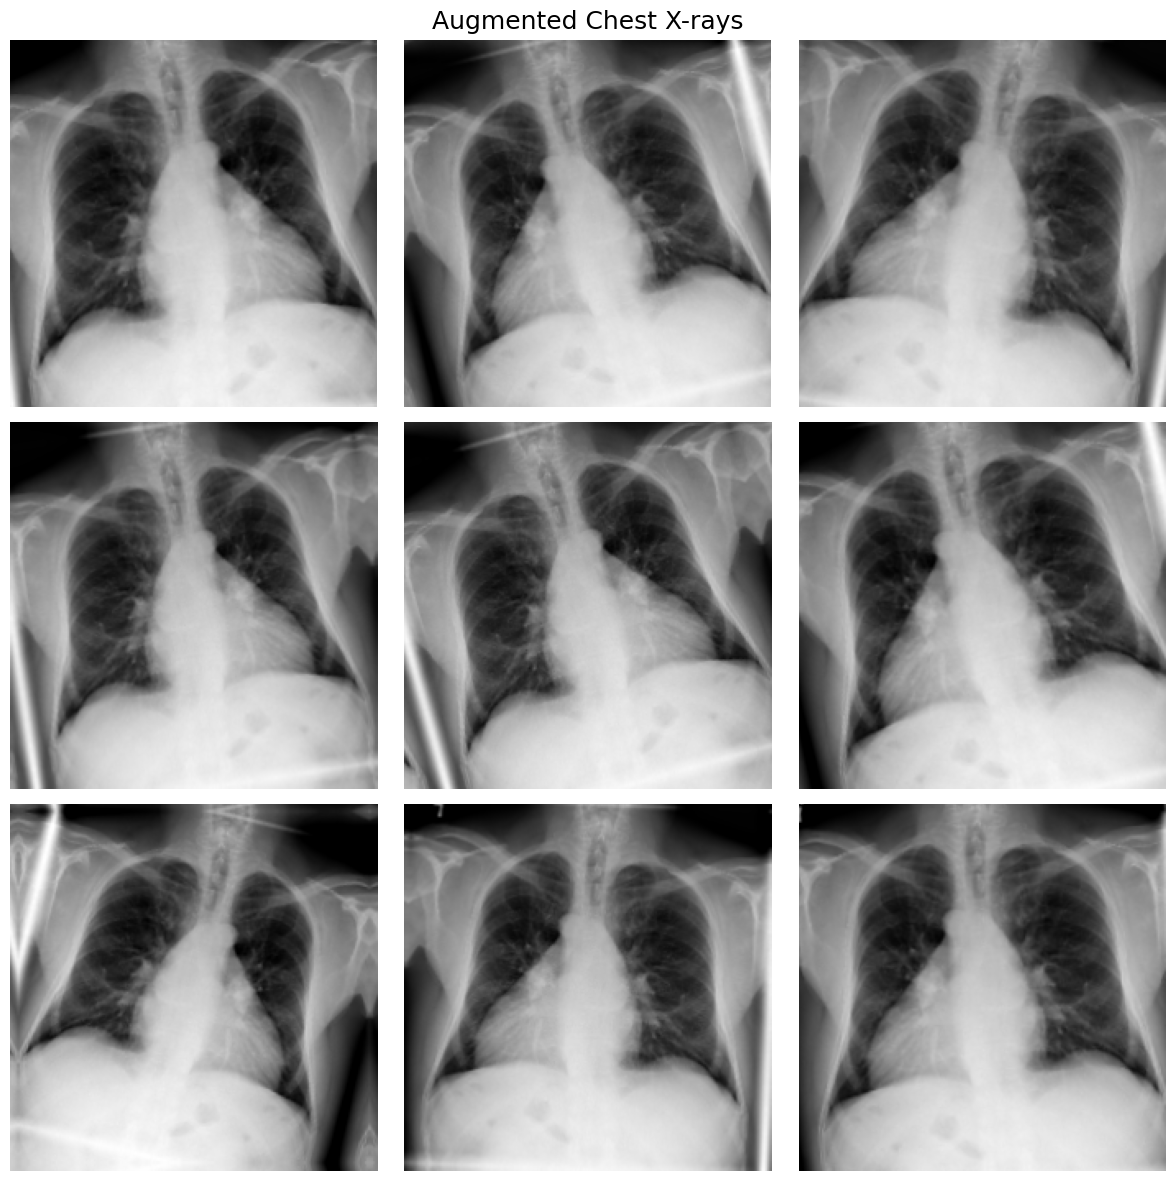

In [123]:
# ====================================================
# Visualize Data Augmentation
# ====================================================

# Always start from the original image
sample_image, sample_label = load_image(
    train_paths[0],
    train_labels[0]
)

# Add ONE batch dimension
sample_batch = tf.expand_dims(sample_image, axis=0)

plt.figure(figsize=(12,12))

for i in range(9):

    augmented = data_augmentation(sample_batch, training=True)

    plt.subplot(3,3,i+1)

    plt.imshow(
        tf.clip_by_value(
            tf.squeeze(augmented),
            0.0,
            1.0
        )
    )

    plt.axis("off")

plt.suptitle("Augmented Chest X-rays", fontsize=18)

plt.tight_layout()

plt.show()

In [124]:
# ====================================================
# Training Configuration
# ====================================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 15

LEARNING_RATE = 1e-4

NUM_CLASSES = 14

print(f"""
Training Configuration

Image Size      : {IMAGE_SIZE}

Batch Size      : {BATCH_SIZE}

Epochs          : {EPOCHS}

Learning Rate   : {LEARNING_RATE}

Output Classes  : {NUM_CLASSES}
""")


Training Configuration

Image Size      : 224

Batch Size      : 32

Epochs          : 15

Learning Rate   : 0.0001

Output Classes  : 14



In [125]:
# ====================================================
# Import DenseNet121
# ====================================================

from tensorflow.keras.applications import DenseNet121

print("DenseNet121 imported successfully!")

DenseNet121 imported successfully!


In [126]:
# ====================================================
# Create DenseNet121 Base Model
# ====================================================

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print(base_model.summary())

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

None


In [127]:
# ====================================================
# Freeze Base Model
# ====================================================

base_model.trainable = False

print("Base Model Trainable:", base_model.trainable)

Base Model Trainable: False


In [128]:
# ====================================================
# Model Parameters
# ====================================================

print("Total Parameters :", base_model.count_params())

Total Parameters : 7037504


In [129]:
# ====================================================
# Build Medical X-ray Classification Model
# ====================================================

from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224,224,3))

# Data Augmentation
x = data_augmentation(inputs)

# DenseNet121 Feature Extractor
x = base_model(x, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Dropout
x = layers.Dropout(0.30)(x)

# Dense Layer
x = layers.Dense(
    256,
    activation="relu"
)(x)

# Second Dropout
x = layers.Dropout(0.20)(x)

# Output Layer
outputs = layers.Dense(
    14,
    activation="sigmoid"
)(x)

model = Model(inputs, outputs)

print("Medical CNN Created Successfully!")

Medical CNN Created Successfully!


In [130]:
# ====================================================
# Model Summary
# ====================================================

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,303,502 (27.86 MB)

 Trainable params: 265,998 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

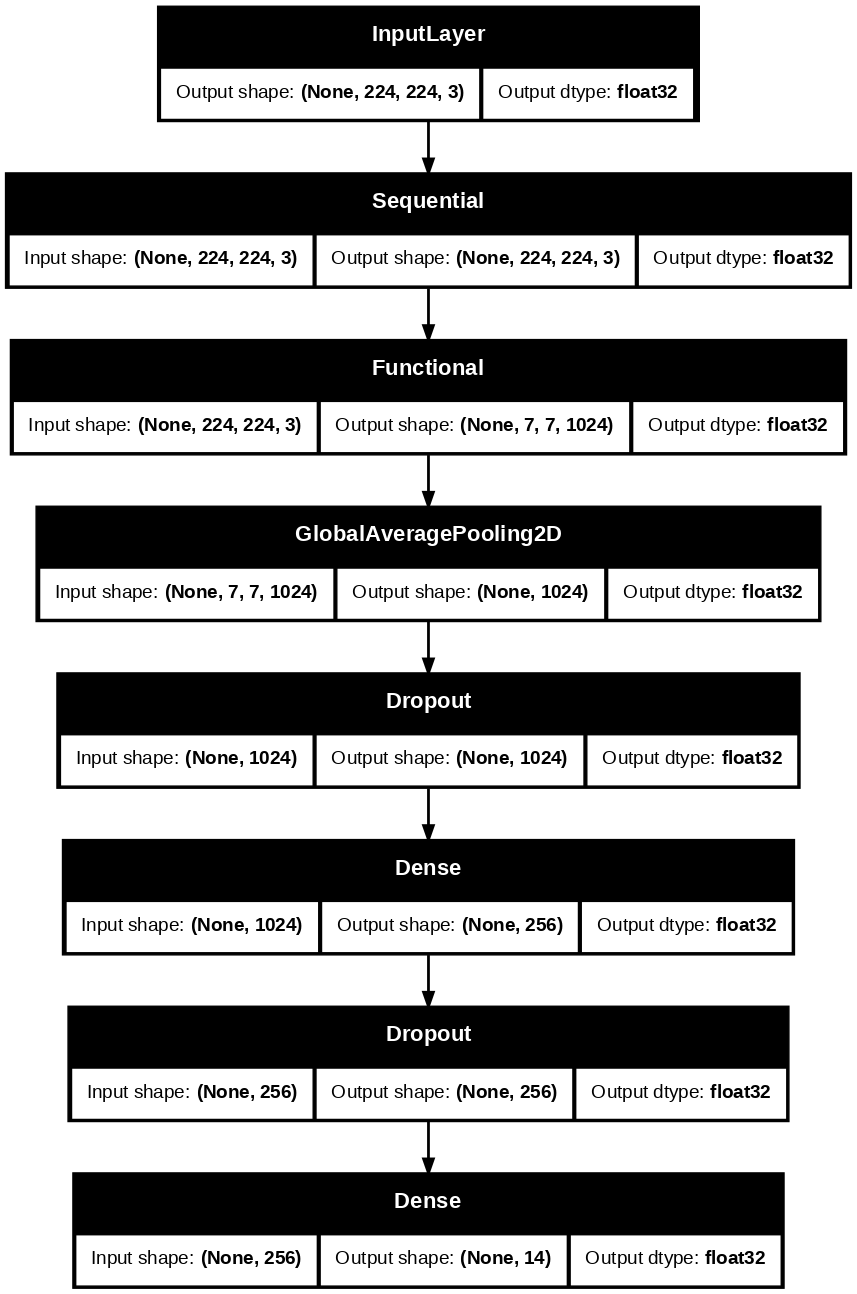

In [131]:
# ====================================================
# Plot Model Architecture
# ====================================================

tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    expand_nested=False,
    dpi=100
)

In [132]:
# ====================================================
# Compile Model
# ====================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [133]:
# ====================================================
# Training Callbacks
# ====================================================

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_auc",

    mode="max",

    save_best_only=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)

callbacks = [

    early_stop,

    checkpoint,

    reduce_lr

]

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


In [134]:
# ====================================================
# Compute Positive Class Weights
# ====================================================

num_samples = len(train_df)

class_weights = {}

print("=" * 60)
print("Positive Class Weights")
print("=" * 60)

for disease in DISEASES:

    positives = train_df[disease].sum()

    negatives = num_samples - positives

    weight = negatives / positives

    class_weights[disease] = weight

    print(f"{disease:<22}: {weight:.2f}")

Positive Class Weights
Atelectasis           : 8.61
Cardiomegaly          : 40.62
Consolidation         : 23.17
Edema                 : 47.58
Effusion              : 7.35
Emphysema             : 44.25
Fibrosis              : 66.95
Hernia                : 500.82
Infiltration          : 4.69
Mass                  : 18.09
Nodule                : 16.78
Pleural_Thickening    : 31.96
Pneumonia             : 78.00
Pneumothorax          : 19.98


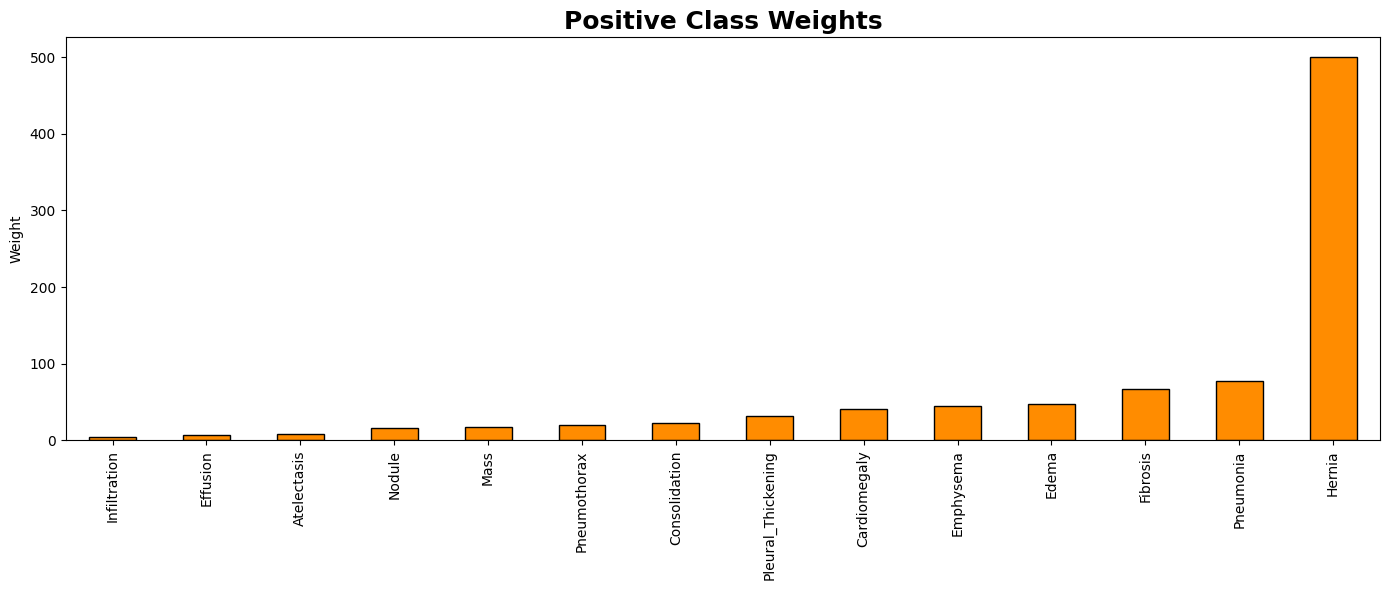

In [135]:
# ====================================================
# Visualize Class Weights
# ====================================================

weights = pd.Series(class_weights)

plt.figure(figsize=(14,6))

weights.sort_values().plot(
    kind="bar",
    color="darkorange",
    edgecolor="black"
)

plt.title(
    "Positive Class Weights",
    fontsize=18,
    weight="bold"
)

plt.ylabel("Weight")

plt.tight_layout()

plt.show()

In [136]:
# ====================================================
# Create Positive Weight Tensor
# ====================================================

positive_weights = np.array(
    [class_weights[d] for d in DISEASES],
    dtype=np.float32
)

positive_weights = tf.constant(positive_weights)

print("Positive Weight Tensor")

positive_weights

Positive Weight Tensor


<tf.Tensor: shape=(14,), dtype=float32, numpy=
array([  8.605004 ,  40.624653 ,  23.172766 ,  47.580856 ,   7.345039 ,
        44.25239  ,  66.94705  , 500.82123  ,   4.6862698,  18.087547 ,
        16.783806 ,  31.963669 ,  78.00264  ,  19.977581 ], dtype=float32)>

In [137]:
# ====================================================
# Weighted Binary Crossentropy Loss
# ====================================================

def weighted_binary_crossentropy(y_true, y_pred):

    loss = tf.nn.weighted_cross_entropy_with_logits(
        labels=y_true,
        logits=tf.math.log(
            y_pred / (1 - y_pred + 1e-7)
        ),
        pos_weight=positive_weights
    )

    return tf.reduce_mean(loss)

In [138]:
# ====================================================
# Rebuild Model (Logits Version)
# ====================================================

from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# DenseNet121 Backbone
x = base_model(inputs, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.20)(x)

# IMPORTANT: No activation here
outputs = layers.Dense(14)(x)

model = Model(inputs, outputs)

print("Medical CNN (Logits Version) Created Successfully!")

Medical CNN (Logits Version) Created Successfully!


In [139]:
# ====================================================
# Compile Logits Model
# ====================================================

loss_fn = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=loss_fn,

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            threshold=0.0,
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            from_logits=True,
            multi_label=True,
            name="auc"
        ),

        tf.keras.metrics.Precision(
            thresholds=0.0,
            name="precision"
        ),

        tf.keras.metrics.Recall(
            thresholds=0.0,
            name="recall"
        )

    ]

)

print("Compiled Successfully!")

Compiled Successfully!


In [140]:
# ==========================================================
# Create Training Callbacks
# ==========================================================

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_medical_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


In [141]:
# ==========================================================
# Final Dataset Verification
# ==========================================================

print("=" * 50)

print("Training Dataset")
print(train_dataset)

print()

print("Validation Dataset")
print(val_dataset)

print()

print("Testing Dataset")
print(test_dataset)

print("=" * 50)

Training Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

Validation Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

Testing Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>


In [142]:
print("Training Batches :", len(train_dataset))
print("Validation Batches :", len(val_dataset))
print("Testing Batches :", len(test_dataset))

Training Batches : 2808
Validation Batches : 365
Testing Batches : 332


In [143]:
# ==========================================================
# Check Trainable Layers
# ==========================================================

print("="*60)
print("Trainable Layers")
print("="*60)

trainable = 0
non_trainable = 0

for layer in model.layers:

    if layer.trainable:
        trainable += 1
        print(f"✅ {layer.name}")

    else:
        non_trainable += 1

print("\nTrainable Layers :", trainable)
print("Frozen Layers    :", non_trainable)

Trainable Layers
✅ input_layer_8
✅ global_average_pooling2d_3
✅ dropout_6
✅ dense_6
✅ dropout_7
✅ dense_7

Trainable Layers : 6
Frozen Layers    : 1


In [144]:
# ==========================================================
# Save Initial Weights
# ==========================================================

initial_weights = model.get_weights()

print("Initial weights saved successfully!")

Initial weights saved successfully!


In [145]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/kaggle/input/models/siddesh0410/medical-model/keras/default/1/best_medical_model.keras"

model = load_model(MODEL_PATH)

print("✅ Stage 1 Model Loaded Successfully")

✅ Stage 1 Model Loaded Successfully


In [146]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,835,500 (29.89 MB)

 Trainable params: 265,998 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 531,998 (2.03 MB)

In [147]:
# ==========================================================
# Find DenseNet Backbone
# ==========================================================

base_model = None

for layer in model.layers:
    if "densenet" in layer.name.lower():
        base_model = layer
        break

print(base_model)

<Functional name=densenet121, built=True>


In [148]:
# ==========================================================
# Total DenseNet Layers
# ==========================================================

print("Total DenseNet Layers :", len(base_model.layers))


Total DenseNet Layers : 427


In [149]:
# ==========================================================
# Freeze Entire DenseNet
# ==========================================================

base_model.trainable = False

print("DenseNet Frozen")

DenseNet Frozen


In [150]:
# ==========================================================
# Unfreeze Last 50 Layers
# ==========================================================

for layer in base_model.layers[-50:]:
    layer.trainable = True

print("Last 50 DenseNet Layers Unfrozen")

Last 50 DenseNet Layers Unfrozen


In [151]:
# ==========================================================
# Verify Fine-Tuning
# ==========================================================

trainable = 0
frozen = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable += 1
    else:
        frozen += 1

print("Trainable Layers :", trainable)
print("Frozen Layers    :", frozen)

Trainable Layers : 51
Frozen Layers    : 376


In [152]:
# ==========================================================
# Compile for Fine-Tuning
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            threshold=0.0,
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            multi_label=True,
            from_logits=True,
            name="auc"
        ),

        tf.keras.metrics.Precision(
            thresholds=0.0,
            name="precision"
        ),

        tf.keras.metrics.Recall(
            thresholds=0.0,
            name="recall"
        )

    ]

)

print("Fine-Tuning Compilation Complete!")

Fine-Tuning Compilation Complete!


In [153]:
# ==========================================================
# Fine-Tuning Callbacks
# ==========================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_finetuned_model.keras",

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    verbose=1

)

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_auc",

    mode="max",

    factor=0.3,

    patience=2,

    min_lr=1e-7,

    verbose=1

)

callbacks_stage2 = [

    checkpoint,

    early_stop,

    reduce_lr

]

print("✅ Stage 2 Callbacks Ready")

✅ Stage 2 Callbacks Ready


In [154]:
# ==========================================================
# Stage 2 Configuration
# ==========================================================

FINE_TUNE_EPOCHS = 10

print("Fine-Tuning Epochs :", FINE_TUNE_EPOCHS)

print("Learning Rate      : 1e-5")

print("Trainable Layers   :", 51)

Fine-Tuning Epochs : 10
Learning Rate      : 1e-5
Trainable Layers   : 51


In [155]:
# ==========================================================
# Stage 2 Fine-Tuning
# ==========================================================

history_stage2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks_stage2,
    verbose=1
)

print("\n✅ Fine-Tuning Completed!")

Epoch 1/10
   1/2808 ━━━━━━━━━━━━━━━━━━━━ 41:03:04 53s/step - accuracy: 0.9263 - auc: 0.4795 - loss: 0.2736 - precision: 0.5000 - recall: 0.0303

I0000 00:00:1786030683.951055     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2808/2808 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9511 - auc: 0.6629 - loss: 0.1723 - precision: 0.4146 - recall: 0.0171
Epoch 1: val_auc improved from None to 0.72687, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
2808/2808 ━━━━━━━━━━━━━━━━━━━━ 871s 291ms/step - accuracy: 0.9481 - auc: 0.6847 - loss: 0.1732 - precision: 0.4615 - recall: 0.0170 - val_accuracy: 0.9478 - val_auc: 0.7269 - val_loss: 0.1688 - val_precision: 0.5697 - val_recall: 0.0110 - learning_rate: 1.0000e-05
Epoch 2/10
2807/2808 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9514 - auc: 0.6983 - loss: 0.1653 - precision: 0.4798 - recall: 0.0131
Epoch 2: val_auc improved from 0.72687 to 0.73866, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
2808/2808 ━━━━━━━━━━━━━━━━━━━━ 700s 247ms/step - accuracy: 0.9483 - auc: 0.7094 - loss: 0.1693 - precision: 0.5005 - recall: 0.0163 - val_accuracy: 0.9478 

In [156]:
# ==========================================================
# Save Final Model
# ==========================================================

model.save("/kaggle/working/final_model.keras")

print("✅ Final model saved successfully!")

import os

print("\nFiles in /kaggle/working:")
print(os.listdir("/kaggle/working"))

✅ Final model saved successfully!

Files in /kaggle/working:
['final_model.keras', 'model.png', '.virtual_documents', 'best_finetuned_model.keras']


In [157]:
# ==========================================================
# Save Training History
# ==========================================================

import pandas as pd

history_df = pd.DataFrame(history_stage2.history)

history_df.to_csv(
    "/kaggle/working/stage2_training_history.csv",
    index=False
)

print("✅ History Saved")

✅ History Saved


In [158]:
# ==========================================================
# Verify Saved Files
# ==========================================================

import os

print(os.listdir("/kaggle/working"))

['final_model.keras', 'stage2_training_history.csv', 'model.png', '.virtual_documents', 'best_finetuned_model.keras']


In [159]:
from IPython.display import FileLink

print("Download Model:")
display(FileLink("/kaggle/working/best_finetuned_model.keras"))

print("Download Final Model:")
display(FileLink("/kaggle/working/final_model.keras"))

print("Download History:")
display(FileLink("/kaggle/working/stage2_training_history.csv"))

Download Model:


/kaggle/working/best_finetuned_model.keras

Download Final Model:


/kaggle/working/final_model.keras

Download History:


/kaggle/working/stage2_training_history.csv

In [161]:
# ==========================================================
# Load Best Fine-Tuned Model
# ==========================================================

from tensorflow.keras.models import load_model

model = load_model(
    "/kaggle/working/best_finetuned_model.keras",
    compile=False
)

print("✅ Best Fine-Tuned Model Loaded")

✅ Best Fine-Tuned Model Loaded


In [162]:
# ==========================================================
# Compile Model for Evaluation
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(),

    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            threshold=0.0,
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            multi_label=True,
            from_logits=True,
            name="auc"
        ),

        tf.keras.metrics.Precision(
            thresholds=0.0,
            name="precision"
        ),

        tf.keras.metrics.Recall(
            thresholds=0.0,
            name="recall"
        )

    ]
)

print("✅ Ready for Evaluation")

✅ Ready for Evaluation


In [163]:
# ==========================================================
# Evaluate on Test Dataset
# ==========================================================

results = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================")

print("Test Loss      :", results[0])

print("Test Accuracy  :", results[1])

print("Test AUC       :", results[2])

print("Test Precision :", results[3])

print("Test Recall    :", results[4])

print("==============================")

332/332 ━━━━━━━━━━━━━━━━━━━━ 101s 255ms/step - accuracy: 0.9491 - auc: 0.7692 - loss: 0.1615 - precision: 0.5328 - recall: 0.0384

Test Loss      : 0.16150465607643127
Test Accuracy  : 0.9491217136383057
Test AUC       : 0.7691746354103088
Test Precision : 0.5328466892242432
Test Recall    : 0.038436226546764374


In [164]:
# ==========================================================
# Save Test Metrics
# ==========================================================

metrics = {

    "Loss": results[0],

    "Accuracy": results[1],

    "AUC": results[2],

    "Precision": results[3],

    "Recall": results[4]

}

import pandas as pd

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "/kaggle/working/test_metrics.csv",
    index=False
)

metrics_df

,Loss,Accuracy,AUC,Precision,Recall
0,0.161505,0.949122,0.769175,0.532847,0.038436


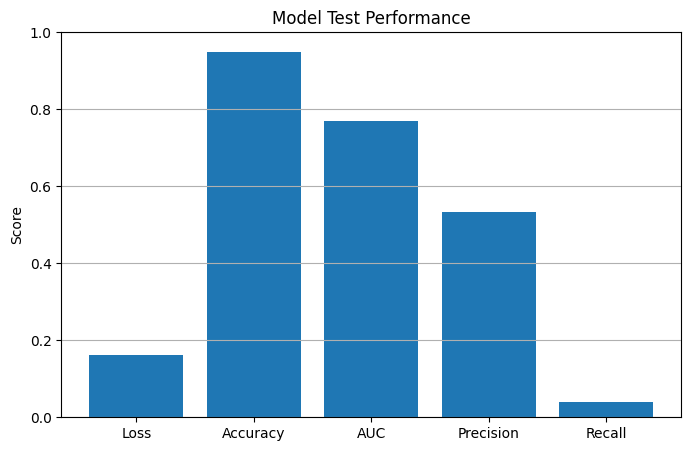

In [165]:
# ==========================================================
# Visualize Test Metrics
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title("Model Test Performance")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

In [166]:
# ==========================================================
# Predict on Test Dataset
# ==========================================================

y_pred_logits = model.predict(test_dataset)

print("Prediction Shape :", y_pred_logits.shape)

332/332 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step
Prediction Shape : (10615, 14)


In [167]:
# ==========================================================
# Convert Logits to Probabilities
# ==========================================================

import tensorflow as tf

y_pred_probs = tf.nn.sigmoid(y_pred_logits).numpy()

print(y_pred_probs.shape)

(10615, 14)


In [168]:
# ==========================================================
# Collect Ground Truth Labels
# ==========================================================

import numpy as np

y_true = np.concatenate(
    [labels for images, labels in test_dataset],
    axis=0
)

print("True Labels Shape :", y_true.shape)

True Labels Shape : (10615, 14)


In [169]:
# ==========================================================
# Verify Prediction Arrays
# ==========================================================

print("Predictions :", y_pred_probs.shape)

print("Ground Truth :", y_true.shape)

Predictions : (10615, 14)
Ground Truth : (10615, 14)


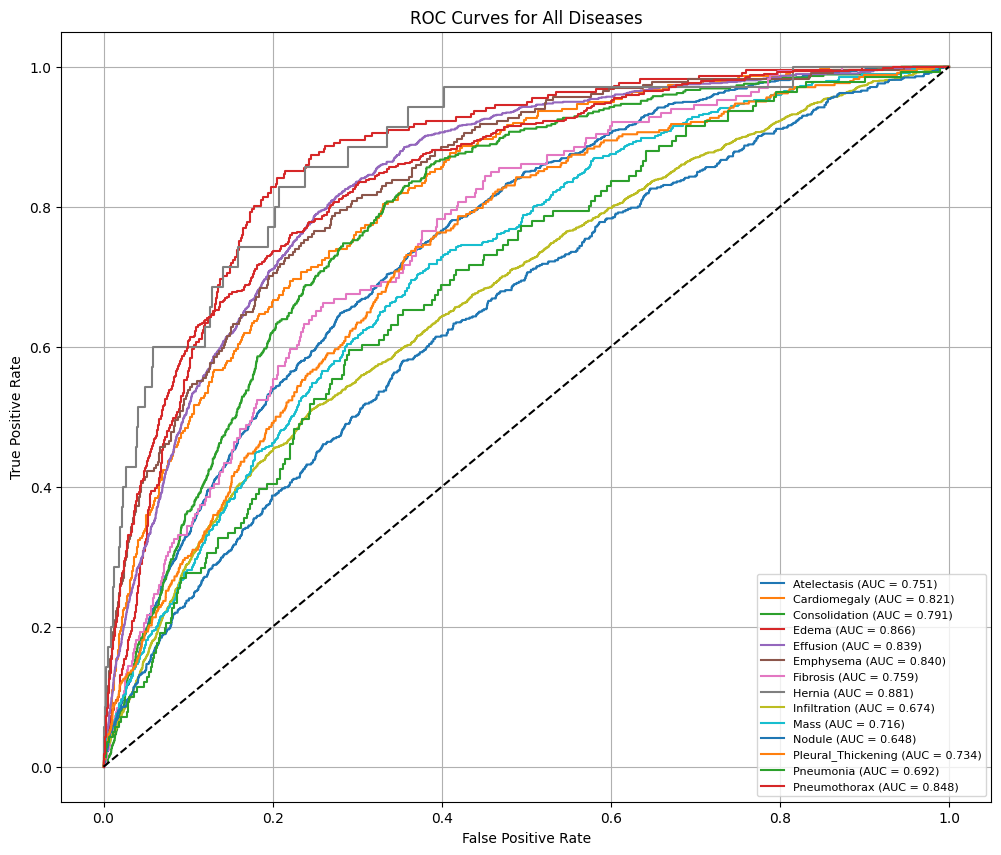

In [170]:
# ==========================================================
# ROC Curve and AUC for Each Disease
# ==========================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

auc_scores = {}

for i, disease in enumerate(DISEASES):

    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])

    roc_auc = auc(fpr, tpr)

    auc_scores[disease] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{disease} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves for All Diseases")

plt.legend(fontsize=8)

plt.grid(True)

plt.show()

In [171]:
# ==========================================================
# Disease-wise AUC Scores
# ==========================================================

import pandas as pd

auc_df = pd.DataFrame(

    auc_scores.items(),

    columns=["Disease","AUC"]

)

auc_df = auc_df.sort_values(

    by="AUC",

    ascending=False

)

auc_df

,Disease,AUC
7,Hernia,0.880894
3,Edema,0.866437
13,Pneumothorax,0.847773
5,Emphysema,0.839873
4,Effusion,0.838632
1,Cardiomegaly,0.820674
2,Consolidation,0.791416
6,Fibrosis,0.758828
0,Atelectasis,0.751063
11,Pleural_Thickening,0.733762


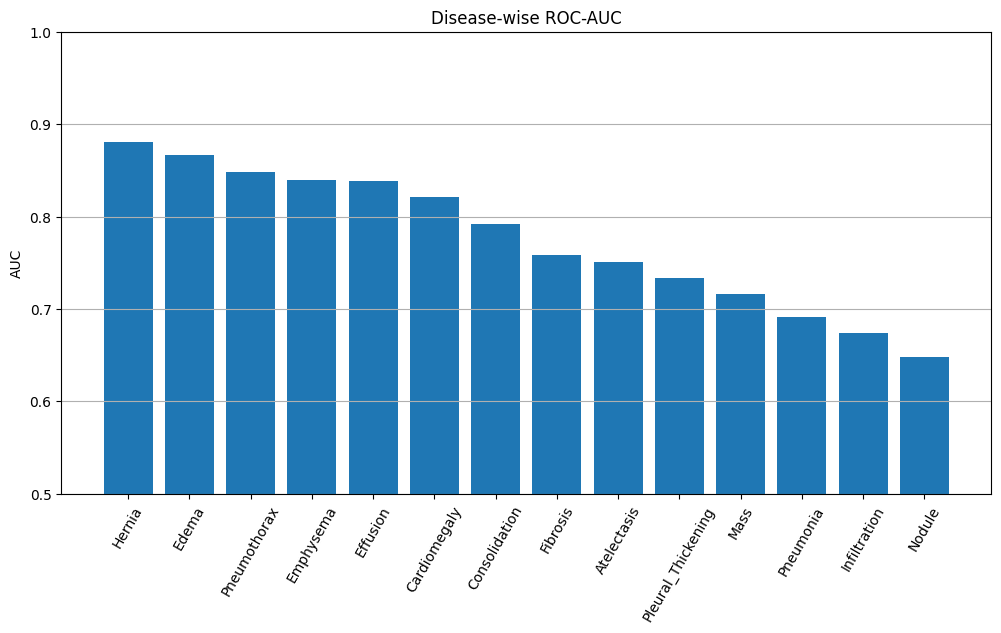

In [172]:
# ==========================================================
# Visualize Disease-wise AUC
# ==========================================================

plt.figure(figsize=(12,6))

plt.bar(
    auc_df["Disease"],
    auc_df["AUC"]
)

plt.xticks(rotation=60)

plt.ylim(0.5,1.0)

plt.ylabel("AUC")

plt.title("Disease-wise ROC-AUC")

plt.grid(axis="y")

plt.show()

In [173]:
# ==========================================================
# Average AUC
# ==========================================================

print("Average Disease AUC:")

print(round(auc_df["AUC"].mean(),4))

Average Disease AUC:
0.7757


In [174]:
# ==========================================================
# Find Best Threshold for Each Disease
# ==========================================================

from sklearn.metrics import precision_recall_curve
import numpy as np
import pandas as pd

best_thresholds = {}

for i, disease in enumerate(DISEASES):

    precision, recall, thresholds = precision_recall_curve(
        y_true[:, i],
        y_pred_probs[:, i]
    )

    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    best_index = np.argmax(f1)

    if best_index >= len(thresholds):
        best_index = len(thresholds) - 1

    best_thresholds[disease] = thresholds[best_index]

threshold_df = pd.DataFrame(
    best_thresholds.items(),
    columns=["Disease", "Best Threshold"]
)

threshold_df

,Disease,Best Threshold
0,Atelectasis,0.179883
1,Cardiomegaly,0.092366
2,Consolidation,0.094164
3,Edema,0.111305
4,Effusion,0.316112
5,Emphysema,0.102542
6,Fibrosis,0.056806
7,Hernia,0.035011
8,Infiltration,0.235247
9,Mass,0.105772


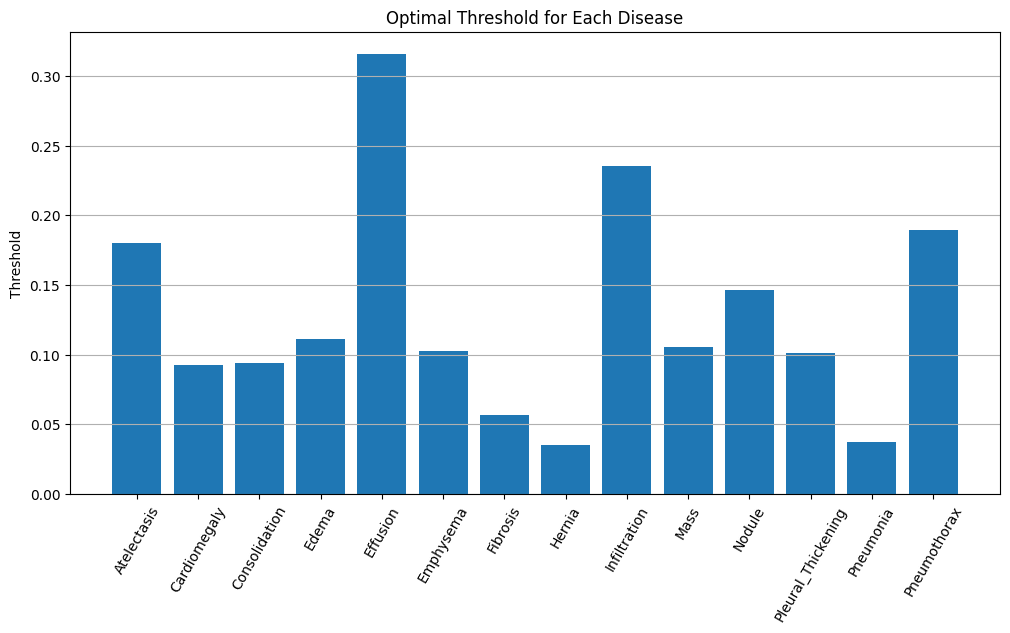

In [175]:
# ==========================================================
# Visualize Best Thresholds
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    threshold_df["Disease"],
    threshold_df["Best Threshold"]
)

plt.xticks(rotation=60)

plt.ylabel("Threshold")

plt.title("Optimal Threshold for Each Disease")

plt.grid(axis="y")

plt.show()

In [176]:
# ==========================================================
# Create Binary Predictions Using Optimal Thresholds
# ==========================================================

y_pred_binary = np.zeros_like(y_pred_probs)

for i, disease in enumerate(DISEASES):

    y_pred_binary[:, i] = (
        y_pred_probs[:, i] >= best_thresholds[disease]
    )

print("Binary Prediction Shape:", y_pred_binary.shape)

Binary Prediction Shape: (10615, 14)


In [177]:
# ==========================================================
# Save Thresholds
# ==========================================================

threshold_df.to_csv(
    "/kaggle/working/optimal_thresholds.csv",
    index=False
)

threshold_df

,Disease,Best Threshold
0,Atelectasis,0.179883
1,Cardiomegaly,0.092366
2,Consolidation,0.094164
3,Edema,0.111305
4,Effusion,0.316112
5,Emphysema,0.102542
6,Fibrosis,0.056806
7,Hernia,0.035011
8,Infiltration,0.235247
9,Mass,0.105772


In [178]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_binary,
    target_names=DISEASES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Atelectasis,0.220693,0.531658,0.311910,995.0
Cardiomegaly,0.187621,0.323333,0.237454,300.0
Consolidation,0.125355,0.586283,0.206547,452.0
Edema,0.131498,0.389140,0.196571,221.0
Effusion,0.400972,0.533549,0.457856,1237.0
Emphysema,0.192771,0.341880,0.246533,234.0
Fibrosis,0.070258,0.180723,0.101180,166.0
Hernia,0.138889,0.142857,0.140845,35.0
Infiltration,0.304965,0.510248,0.381759,1854.0
Mass,0.119475,0.449726,0.188795,547.0


In [179]:
# ==========================================================
# Save Report
# ==========================================================

report_df.to_csv(
    "/kaggle/working/classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


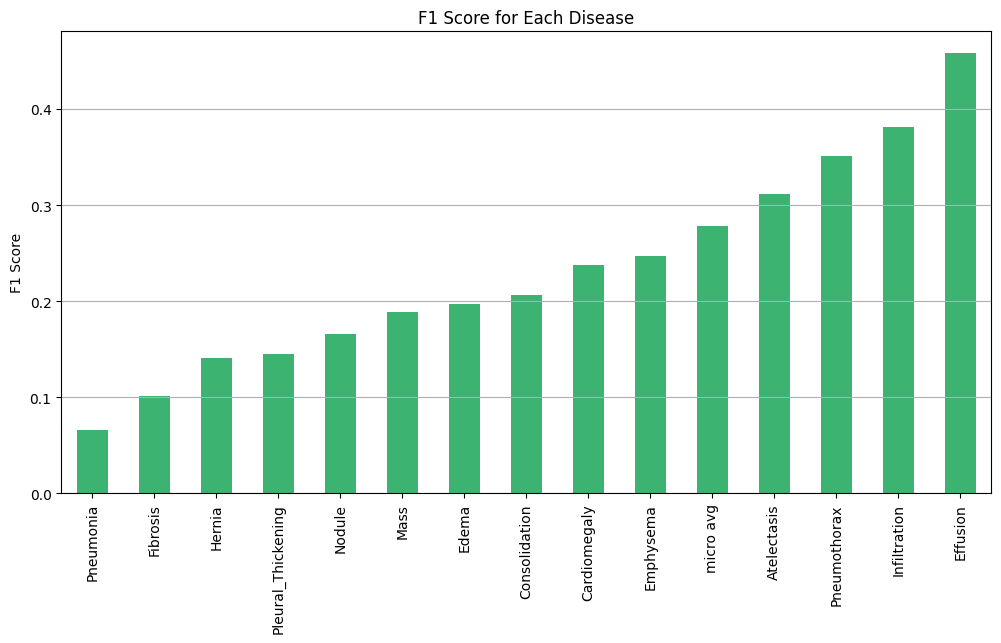

In [180]:
# ==========================================================
# F1 Score of Every Disease
# ==========================================================

plt.figure(figsize=(12,6))

report_df.iloc[:-3]["f1-score"].sort_values().plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("F1 Score for Each Disease")

plt.ylabel("F1 Score")

plt.grid(axis="y")

plt.show()

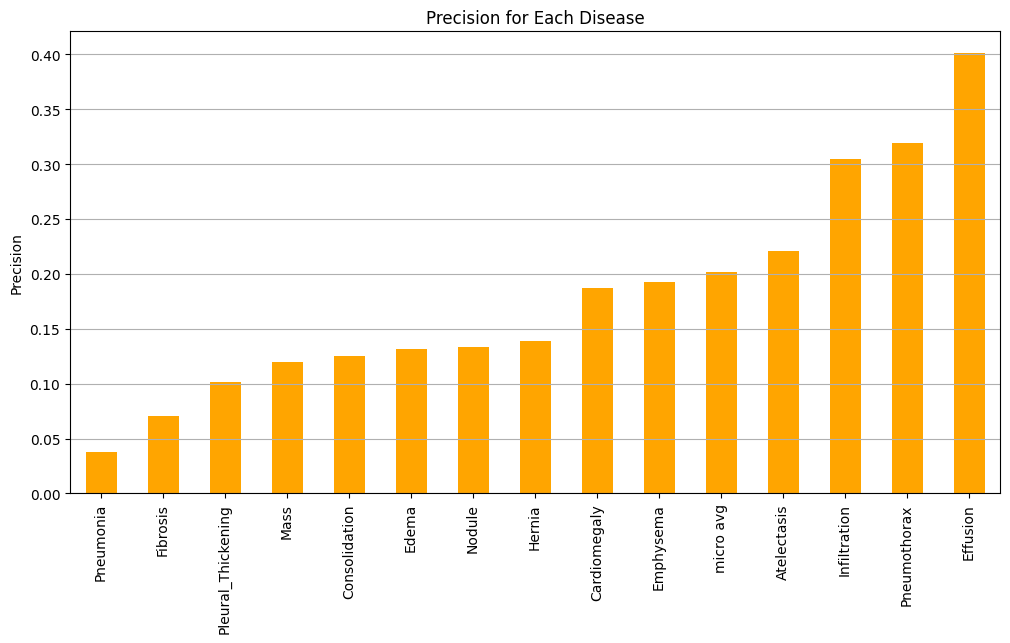

In [181]:
# ==========================================================
# Precision Comparison
# ==========================================================

plt.figure(figsize=(12,6))

report_df.iloc[:-3]["precision"].sort_values().plot(
    kind="bar",
    color="orange"
)

plt.title("Precision for Each Disease")

plt.ylabel("Precision")

plt.grid(axis="y")

plt.show()

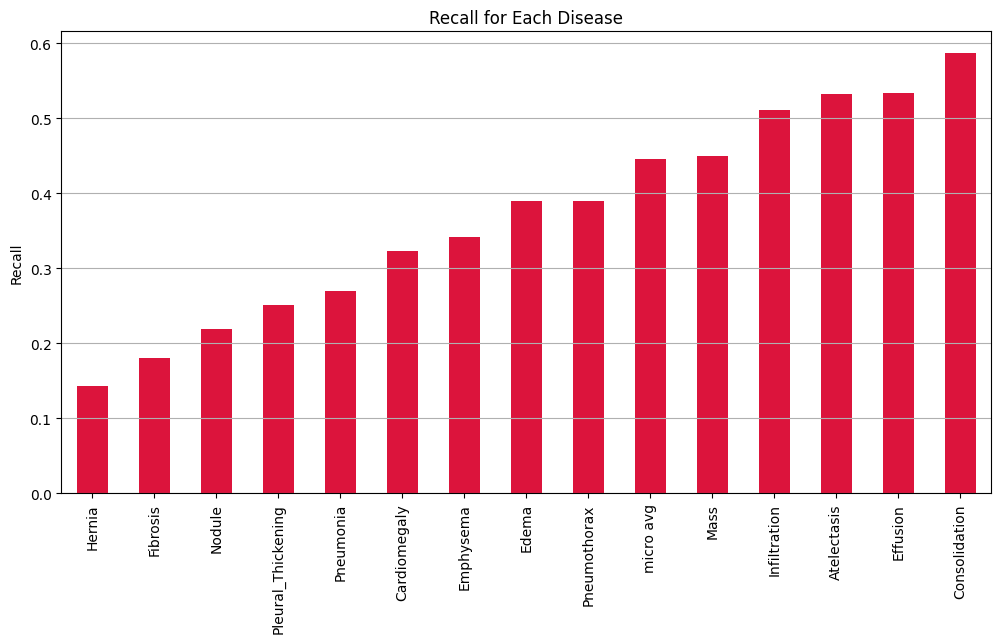

In [182]:
# ==========================================================
# Recall Comparison
# ==========================================================

plt.figure(figsize=(12,6))

report_df.iloc[:-3]["recall"].sort_values().plot(
    kind="bar",
    color="crimson"
)

plt.title("Recall for Each Disease")

plt.ylabel("Recall")

plt.grid(axis="y")

plt.show()

In [183]:
# ==========================================================
# Overall Metrics
# ==========================================================

overall = report_df.loc[
    ["micro avg", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score"]
]

overall

,precision,recall,f1-score
micro avg,0.201968,0.445702,0.277974
macro avg,0.177528,0.365638,0.228434
weighted avg,0.240105,0.445702,0.303075


In [202]:
# ==========================================================
# Disease Names
# ==========================================================

DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

print("Diseases Loaded Successfully!")

Diseases Loaded Successfully!


In [203]:
# ==========================================================
# Select Sample X-ray
# ==========================================================

sample_path = test_paths[25]

print(sample_path)

/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000174_005.png


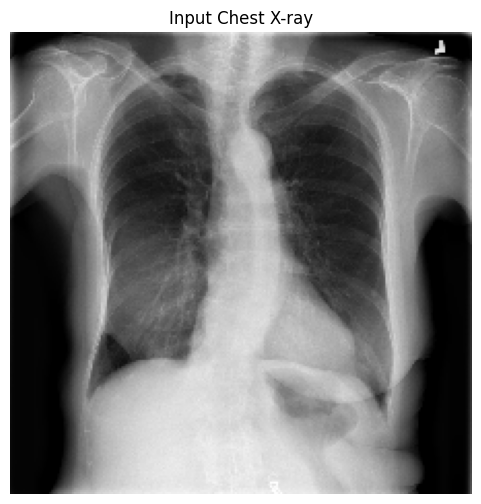

In [204]:
# ==========================================================
# Load Image
# ==========================================================

image = tf.keras.utils.load_img(
    sample_path,
    target_size=(224,224)
)

image_array = tf.keras.utils.img_to_array(image)

image_array = image_array / 255.0

image_input = np.expand_dims(image_array, axis=0)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Chest X-ray")
plt.show()

In [205]:
# ==========================================================
# Predict Diseases
# ==========================================================

prediction = model.predict(image_input)

prediction = prediction[0]

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


array([-3.1638813, -4.483697 , -4.8303895, -7.281447 , -3.4309628,
       -4.3047457, -2.7838438, -6.1066694, -1.8294648, -2.8019435,
       -2.1861796, -2.957414 , -5.255904 , -3.08357  ], dtype=float32)

In [206]:
# ==========================================================
# Display Prediction Probabilities
# ==========================================================

prediction_df = pd.DataFrame({
    "Disease": DISEASES,
    "Probability": prediction
})

prediction_df = prediction_df.sort_values(
    by="Probability",
    ascending=False
)

prediction_df

,Disease,Probability
8,Infiltration,-1.829465
10,Nodule,-2.186180
6,Fibrosis,-2.783844
9,Mass,-2.801944
11,Pleural_Thickening,-2.957414
13,Pneumothorax,-3.083570
0,Atelectasis,-3.163881
4,Effusion,-3.430963
5,Emphysema,-4.304746
1,Cardiomegaly,-4.483697


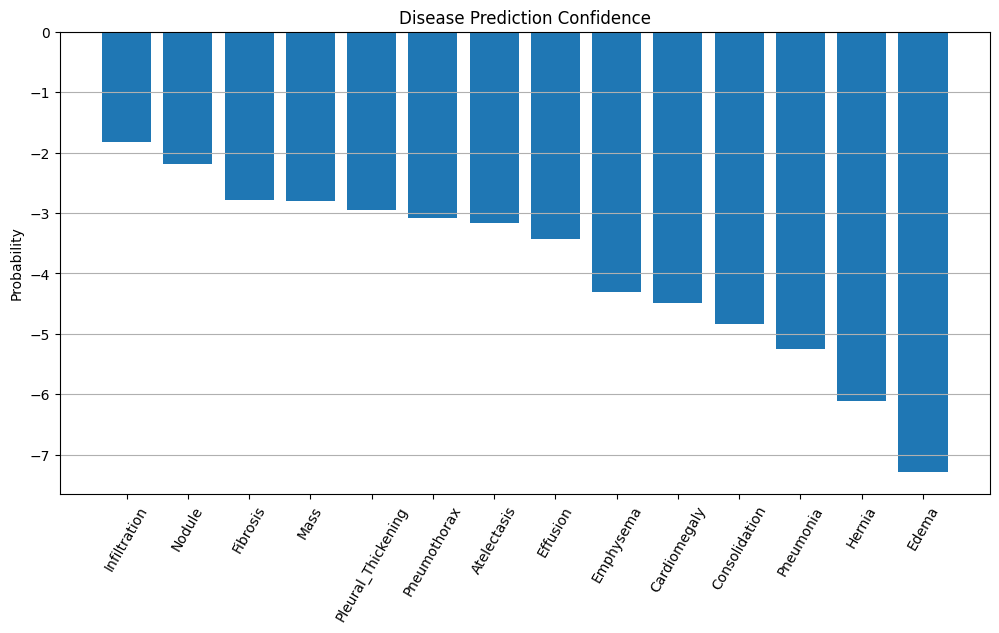

In [207]:
# ==========================================================
# Bar Chart
# ==========================================================

plt.figure(figsize=(12,6))

plt.bar(
    prediction_df["Disease"],
    prediction_df["Probability"]
)

plt.xticks(rotation=60)

plt.ylabel("Probability")

plt.title("Disease Prediction Confidence")

plt.grid(axis="y")

plt.show()

In [209]:
# ==========================================================
# Generate Medical Report
# ==========================================================

def generate_medical_report(predictions, diseases, threshold=0.30):

    detected = []

    for disease, prob in zip(diseases, predictions):

        if prob >= threshold:
            detected.append((disease, prob))

    report = ""

    report += "=============================\n"
    report += "AI MEDICAL REPORT\n"
    report += "=============================\n\n"

    if len(detected) == 0:

        report += "Result: No major disease detected.\n\n"

        report += "Recommendation:\n"

        report += "- Continue regular health checkups.\n"

        report += "- Maintain healthy lifestyle.\n"

        report += "- Consult doctor if symptoms persist."

    else:

        report += "Detected Diseases:\n\n"

        for disease, prob in detected:

            report += f"• {disease} ({prob:.2%})\n"

        report += "\n"

        report += "Recommendation:\n"

        report += "- Clinical evaluation recommended.\n"

        report += "- Confirm diagnosis with radiologist.\n"

        report += "- Additional tests may be required.\n"

        report += "- Do not rely solely on AI predictions."

    return report

In [210]:
report = generate_medical_report(
    prediction,
    DISEASES
)

print(report)

AI MEDICAL REPORT

Result: No major disease detected.

Recommendation:
- Continue regular health checkups.
- Maintain healthy lifestyle.
- Consult doctor if symptoms persist.


In [212]:
with open("/kaggle/working/medical_report.txt","w") as f:

    f.write(report)

print("Medical report saved successfully.")

Medical report saved successfully.


In [213]:
prediction_df

,Disease,Probability
8,Infiltration,-1.829465
10,Nodule,-2.186180
6,Fibrosis,-2.783844
9,Mass,-2.801944
11,Pleural_Thickening,-2.957414
13,Pneumothorax,-3.083570
0,Atelectasis,-3.163881
4,Effusion,-3.430963
5,Emphysema,-4.304746
1,Cardiomegaly,-4.483697


In [214]:
print(report)

AI MEDICAL REPORT

Result: No major disease detected.

Recommendation:
- Continue regular health checkups.
- Maintain healthy lifestyle.
- Consult doctor if symptoms persist.


In [215]:
# Save prediction table

prediction_df.to_csv(
    "/kaggle/working/sample_prediction.csv",
    index=False
)

print("Prediction saved.")

Prediction saved.


In [216]:
# Save overall evaluation

overall.to_csv(
    "/kaggle/working/overall_metrics.csv"
)

print("Overall metrics saved.")

Overall metrics saved.


In [218]:
# Save disease AUC

auc_df.to_csv(
    "/kaggle/working/disease_auc.csv",
    index=False
)

print("Disease AUC saved.")

Disease AUC saved.
